In [1]:

import numpy as np
import soundfile as sf
from numpy.typing import NDArray, ArrayLike
from typing import Union
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import *

Here we are testing the code used to generate impulse responses by shaping white gaussian noise.   
The envelope is adjusted to match a target EDC, following the common slope model.  
First, define the T and A energy decay parameters (in the Schroeder backward integration sense)  
(It's the )


In [2]:
T_s = np.array([[0.5, 1.5],
                [0.75, 1.75], 
                [1, 2],
                [1, 2.5],
                [0.75, 2], 
                [0.5, 1.5]])  # T60 in seconds
A_s = np.array([[2, 0.1],
                [1.5, 0.5],
                [1.5, 0.5],
                [3, 1.75],
                [2.5, 1],
                [1.5, 0.5]])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples
bands = [125, 250, 500, 1000, 2000, 4000]
time_axis = np.arange(0, L) / fs

### Target Energy Decay Curve 
Construct the EDC of the desired RIR from the T_s and A_s values

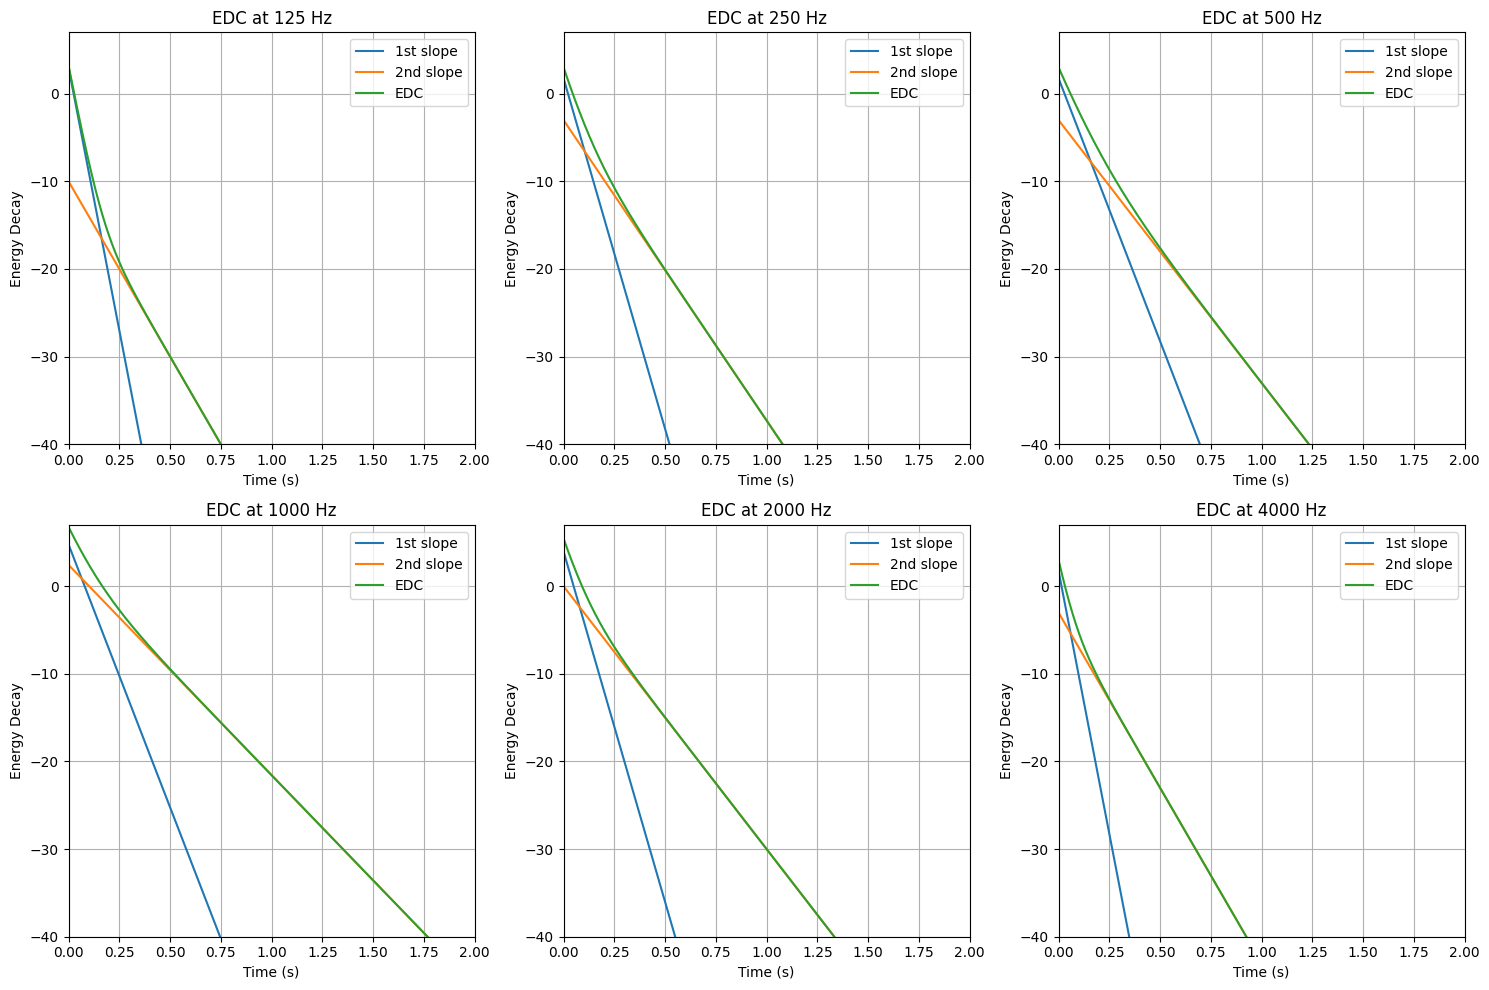

In [3]:
envelope_kernel = decay_kernel( T_s,
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc = np.expand_dims(A_s,1)*envelope_kernel
n_bands = len(bands)
plt.figure(figsize=(15, 10))
for i in range(n_bands):
    plt.subplot(2, 3, i+1)
    plt.plot(time_axis, 10*np.log10(edc[i, :, 0]), label='1st slope')
    plt.plot(time_axis, 10*np.log10(edc[i, :, 1]), label='2nd slope')
    plt.plot(time_axis, 10*np.log10(np.sum(edc[i, :, :], axis=-1)), label='EDC')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy Decay')
    plt.legend()
    plt.title(f'EDC at {bands[i]} Hz')
    plt.ylim([-40, 7])
    plt.xlim([0, 2])
    plt.grid(True)

plt.tight_layout()
plt.show()

### Shaped Noise
Here the Schroeder T and A values are adapted and used to define the envelopes that are then used to shape the white gaussian noise sequence


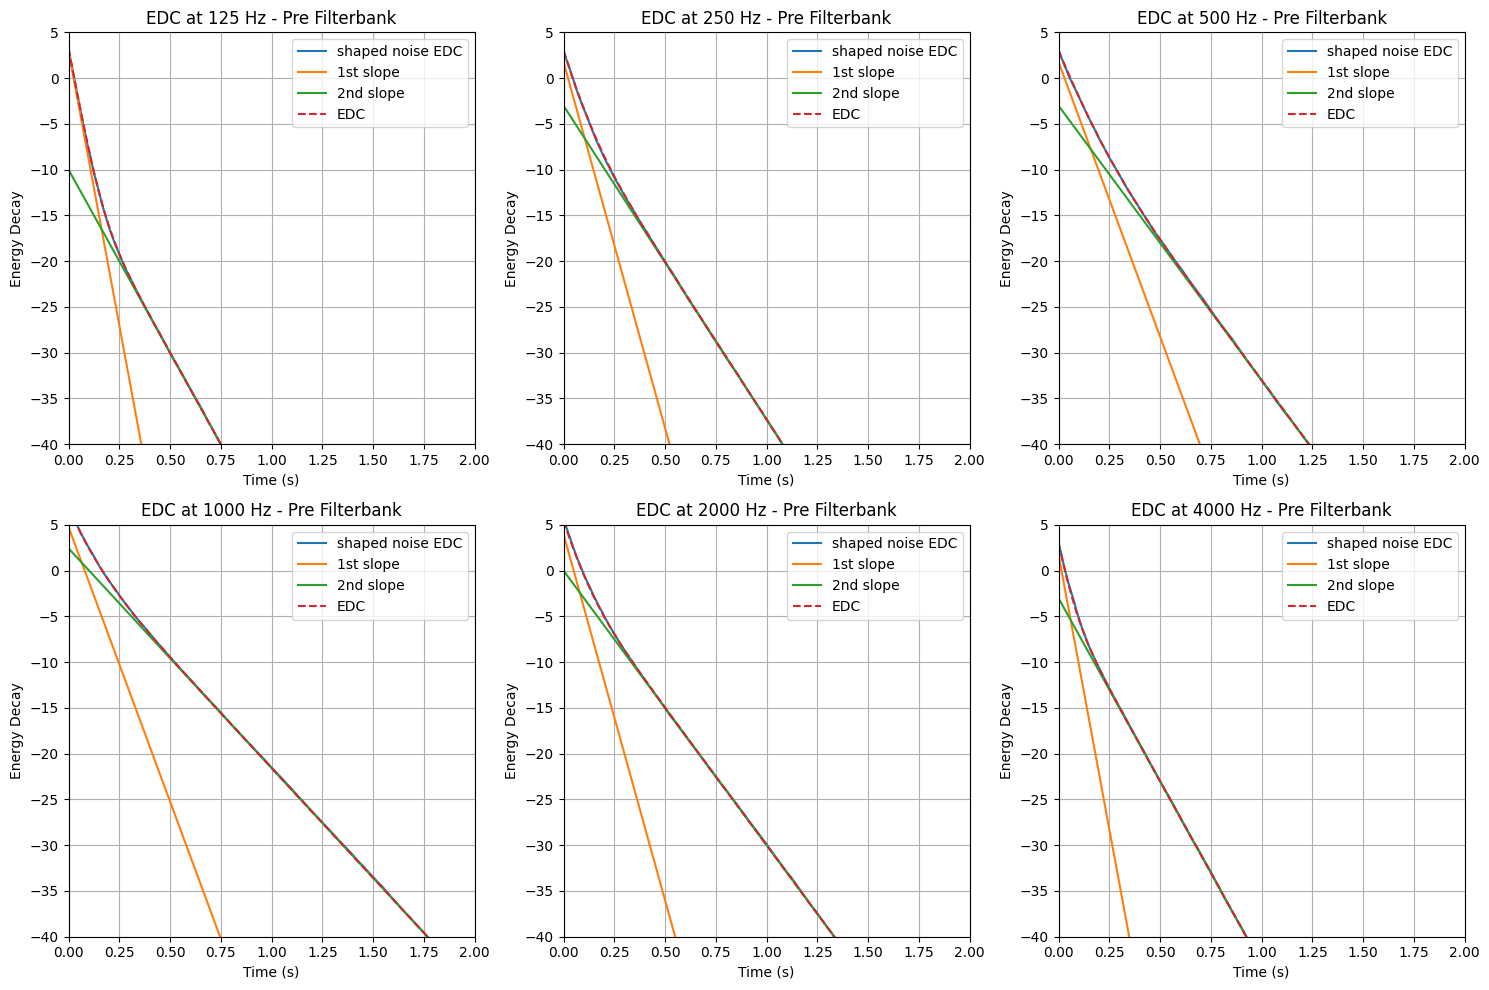

In [4]:
T_e = 2 * T_s
A_e = np.sqrt(A_s) # * np.sqrt(1-np.exp(-np.log(1e6)/fs/T_s))
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalize_envelope=True,
                                add_noise=False)
gaussian_noise = np.random.randn(n_bands, L, n_slopes) # one gaussian noise sequence per frequency band 

shaped_noise = (np.expand_dims(A_e, 1)*envelope_kernel)*gaussian_noise
# use schroeder backward integration to get the EDC
sn_int = schroeder_backward_int(np.sum(shaped_noise, axis=-1), normalize=False)
# TODO: apply filter bank and sum the bands to get the EDC
plt.figure(figsize=(15, 10))
for i in range(len(bands)):
    plt.subplot(2, 3, i+1)
    plt.plot(time_axis, 10*np.log10(sn_int[i, :]), label='shaped noise EDC')
    plt.plot(time_axis, 10*np.log10(edc[i, :, 0]), label='1st slope')
    plt.plot(time_axis, 10*np.log10(edc[i, :, 1]), label='2nd slope')
    plt.plot(time_axis, 10*np.log10(np.sum(edc[i, :, :], axis=-1)), '--', label='EDC')
    plt.xlabel('Time (s)')
    plt.ylabel('Energy Decay')
    plt.legend()
    plt.title(f'EDC at {bands[i]} Hz - Pre Filterbank')
    plt.ylim([-40, 5])
    plt.xlim([0, 2])
    plt.grid(True)

plt.tight_layout()
plt.show()